#Wine quality prediction(Classification)

##Objective

To predict wine quality using classification models.

Design Decisions

- The original quality scores are regrouped into three categories:
    -  Low (≤5)

    -  Medium (=6)

    -  High (≥7)

-  Red and white wines are analysed separately.

-  At least three classification models are compared.

-  Evaluation metrics are selected based on classification performance.









In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

##Load White Wine Dataset

In [ ]:
from google.colab import files
files.upload()

Saving winequality-white.csv to winequality-white (1).csv


{'winequality-white (1).csv': b'"fixed acidity";"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"\n7;0.27;0.36;20.7;0.045;45;170;1.001;3;0.45;8.8;6\n6.3;0.3;0.34;1.6;0.049;14;132;0.994;3.3;0.49;9.5;6\n8.1;0.28;0.4;6.9;0.05;30;97;0.9951;3.26;0.44;10.1;6\n7.2;0.23;0.32;8.5;0.058;47;186;0.9956;3.19;0.4;9.9;6\n7.2;0.23;0.32;8.5;0.058;47;186;0.9956;3.19;0.4;9.9;6\n8.1;0.28;0.4;6.9;0.05;30;97;0.9951;3.26;0.44;10.1;6\n6.2;0.32;0.16;7;0.045;30;136;0.9949;3.18;0.47;9.6;6\n7;0.27;0.36;20.7;0.045;45;170;1.001;3;0.45;8.8;6\n6.3;0.3;0.34;1.6;0.049;14;132;0.994;3.3;0.49;9.5;6\n8.1;0.22;0.43;1.5;0.044;28;129;0.9938;3.22;0.45;11;6\n8.1;0.27;0.41;1.45;0.033;11;63;0.9908;2.99;0.56;12;5\n8.6;0.23;0.4;4.2;0.035;17;109;0.9947;3.14;0.53;9.7;5\n7.9;0.18;0.37;1.2;0.04;16;75;0.992;3.18;0.63;10.8;5\n6.6;0.16;0.4;1.5;0.044;48;143;0.9912;3.54;0.52;12.4;7\n8.3;0.42;0.62;19.25;0.04;41;172;1.0002;2.98;0.67;9.7;5\n

##Dataset description (White wine)
Features are physicochemical properties (e.g., acidity, sugar, chlorides).

Target is the original quality score (integer).

We convert it into a 3-class label for classification.

In [ ]:
white = pd.read_csv('winequality-white.csv', sep =";")
display(white.head())
display(white.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [ ]:
def regroup_quality(q):
  if q <= 5:
    return "Low"
  elif q == 6:
    return "Medium"
  else:
    return "High"

white['quality_label'] = white["quality"].apply(regroup_quality)



print("Original quality distribution:")
print(white['quality'].value_counts().sort_index())

print("\nRegrouped label distribution:")
print(white['quality_label'].value_counts())

print("\nRegrouped label distribution(percentage):")
print(white['quality_label'].value_counts(normalize=True)*100)


Original quality distribution:
quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64

Regrouped label distribution:
quality_label
Medium    2198
Low       1640
High      1060
Name: count, dtype: int64

Regrouped label distribution(percentage):
quality_label
Medium    44.875459
Low       33.483054
High      21.641486
Name: proportion, dtype: float64


##Data Balance
From the regroup quality label we can tell that it is imbalance but not too extreme.

In [ ]:

#split the data to train 80%   test 20%
X = white.drop(['quality','quality_label'] ,axis =1)
y = white['quality_label']
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state =42,
    stratify = y
    )

print(f"Train shape : {X_train.shape},{y_train.shape}")
print(f"Test shape : {X_test.shape},{y_test.shape}")

Train shape : (3918, 11),(3918,)
Test shape : (980, 11),(980,)


##Models

1.Logistic Regression : linear classifier baseline

2.Random forest : non-linear ensemble model

3.Multilayer perceptron : non-linear neural model


In [ ]:
#scaling for Logistic regression and mlp
scale = StandardScaler()
X_train_scaled =scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

#logistic regression
log_reg = LogisticRegression(max_iter=1000)

#Random Forest
forest = RandomForestClassifier(n_estimators=100,
                                  max_depth = None,
                                  random_state = 42
                                  )
#Multilayer perceptron
mlp = MLPClassifier(hidden_layer_sizes= (64,32),
                    activation = "relu",
                    solver = "adam",
                    max_iter= 1000,
                    random_state=42
                    )


##Evaluation metrics
-  Accuracy: overall correctness
-  Precision/Recall/F1: class-wise performance (important under imbalance)
-  Confusion Matrix: shows where misclassifications occur


======Model : Logistic Regression  White wine ==========
Accuracy: 0.5612244897959183
              precision    recall  f1-score   support

        High       0.52      0.35      0.42       212
         Low       0.66      0.56      0.61       328
      Medium       0.52      0.66      0.58       440

    accuracy                           0.56       980
   macro avg       0.57      0.53      0.54       980
weighted avg       0.57      0.56      0.56       980



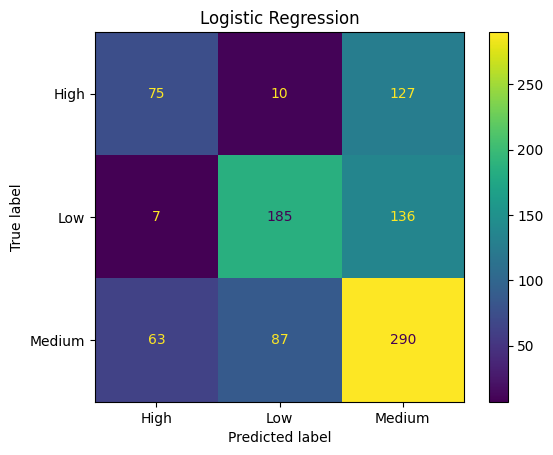

======Model : Random Forest  White wine ==========
Accuracy: 0.726530612244898
              precision    recall  f1-score   support

        High       0.76      0.63      0.69       212
         Low       0.78      0.73      0.75       328
      Medium       0.68      0.78      0.73       440

    accuracy                           0.73       980
   macro avg       0.74      0.71      0.72       980
weighted avg       0.73      0.73      0.73       980



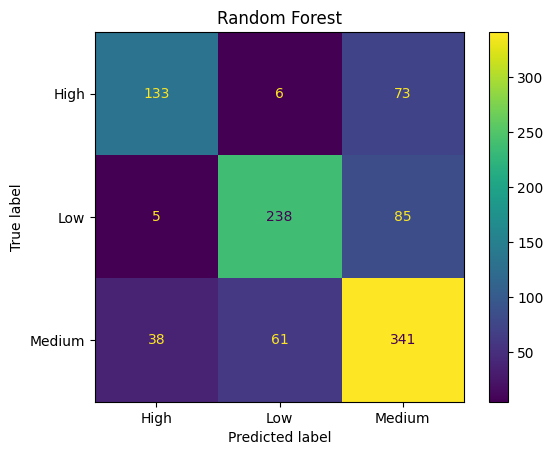

======Model : Multilayer Perceptron  White wine ==========
Accuracy: 0.6510204081632653
              precision    recall  f1-score   support

        High       0.60      0.57      0.58       212
         Low       0.69      0.70      0.70       328
      Medium       0.64      0.65      0.65       440

    accuracy                           0.65       980
   macro avg       0.64      0.64      0.64       980
weighted avg       0.65      0.65      0.65       980



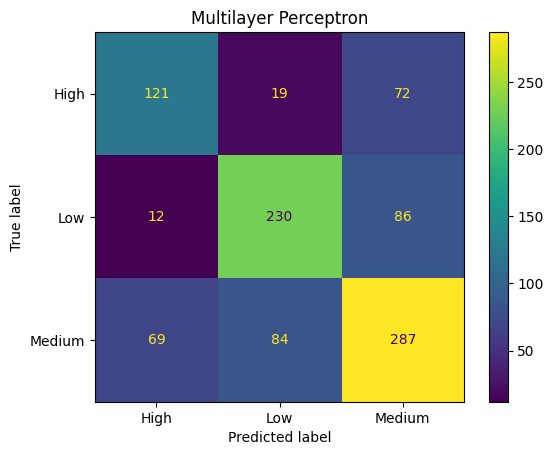

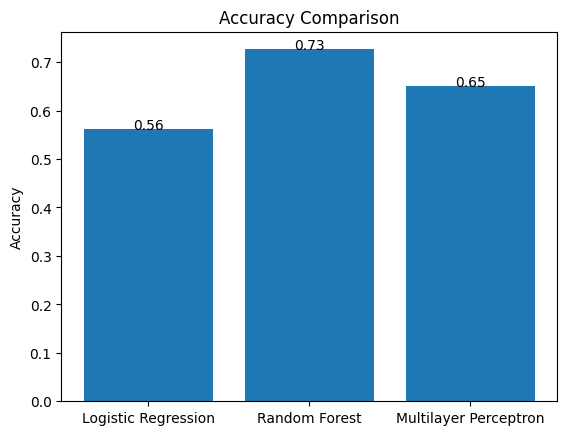

In [ ]:
def evaluation ():
  names = []
  accs = []

  models = {
      "Logistic Regression" : (log_reg,True),
      "Random Forest" : (forest,False),
      "Multilayer Perceptron" : (mlp,True)
  }

  for name, (model,needs_scaling) in models.items():

    if needs_scaling:
      Xtr = X_train_scaled
      Xte = X_test_scaled
    else:
            Xtr = X_train
            Xte = X_test

    model.fit(Xtr,y_train)
    y_pred = model.predict(Xte)


    print(f"======Model : {name}  White wine ==========")
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(name)
    plt.show()
    names.append(name)
    accs.append(acc)



  plt.figure()
  plt.bar(names, accs)
  plt.ylabel("Accuracy")
  plt.title("Accuracy Comparison")
  for i, v in enumerate(accs):
      plt.text(i, v, f"{v:.2f}", ha="center")

evaluation()

##Balance Confirmation
From the evaluation we conclude that the imbalance did not affect the model too much.
Because :
-  the macro average and weighted average is similar
-  the minority class('high') is not ignored (the recall is not low)
-   Performance is relatively balanced (no strong biased)

##Discussion
-  The regrouping converts the original integer quality scores into 3 categories, enabling a clearer classification task.
-  Logistic Regression provides a strong linear baseline
-  Random Forest typically performs best when relationships are non-linear.
-  Multilayer Perception provides nonlinear neural model

The confusion matrices and class-wise precision/recall/F1 explain which quality categories are most commonly confused.